## PCA Code

In [88]:
import numpy as np 
import pandas as pd

np.random.seed(23)

In [89]:
mu_vector1= np.array([0,0,0]) ## This defines the mean (center) of the distribution.

# Because there are 3 values:  mu = [0,0,0] 

# your data has 3 features/dimensions:

# Feature 1 → mean = 0
# Feature 2 → mean = 0
# Feature 3 → mean = 0
# So, roughly, the points will be centered around: (0,0,0)


cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]]) ## Covariance matrix, This tells NumPy about the variance and relationship between the three features.

# 1  0  0
# 0  1  0
# 0  0  1

# mean:

# Feature 1 variance = 1
# Feature 2 variance = 1
# Feature 3 variance = 1

# Since:

# sigma = sqrt{variance} = sqrt{1}=1 
# each feature has standard deviation 1.
# The zeros outside the diagonal mean:
# Cov(X_1,X_2)=0 and Cov(X_1,X_3)=0 and Cov(X_2,X_3)=0

## This is like an identity matrix 

class1_sample = np.random.multivariate_normal(mu_vector1,cov_mat1,20) ## Generate the samples

# mean          = [0, 0, 0]
# covariance    = identity matrix
# samples       = 20
# Generate 20 random 3D observations from a Gaussian distribution centered at [0,0,0], 
# with variance 1 in every dimension and no correlation between dimensions.


In [90]:
class1_sample.shape

(20, 3)

In [91]:
class1_sample

array([[ 0.66698806,  0.02581308, -0.77761941],
       [ 0.94863382,  0.70167179, -1.05108156],
       [-0.36754812, -1.13745969, -1.32214752],
       [ 1.77225828, -0.34745899,  0.67014016],
       [ 0.32227152,  0.06034293, -1.04345   ],
       [-1.00994188,  0.44173637,  1.12887685],
       [-1.83806777, -0.93876863, -0.20184052],
       [ 1.04537128,  0.53816197,  0.81211867],
       [ 0.2411063 , -0.95250953, -0.13626676],
       [ 1.26724821,  0.17363364, -1.22325477],
       [ 1.41531998,  0.45771098,  0.72887584],
       [ 1.96843473, -0.54778801, -0.67941827],
       [-2.50623032,  0.14696049,  0.60619549],
       [-0.02253889,  0.01342226,  0.93594489],
       [ 0.42062266,  0.41161964, -0.07132392],
       [-0.04543758,  1.04088597, -0.09403473],
       [-0.42084395, -0.55198856, -0.12109755],
       [ 0.19014136,  0.51213739,  0.13153847],
       [-0.33161712, -1.63238628,  0.61911407],
       [-0.99257378, -0.16134639,  1.19240433]])

In [92]:
df=pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target']=1

df

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1
5,-1.009942,0.441736,1.128877,1
6,-1.838068,-0.938769,-0.201841,1
7,1.045371,0.538162,0.812119,1
8,0.241106,-0.952510,-0.136267,1
9,1.267248,0.173634,-1.223255,1


In [93]:
mu_vector2= np.array([1,1,1]) ## This defines the mean (center) of the distribution.
cov_mat2=np.array([[1,0,0],[0,1,0],[0,0,1]])

class2_sample=np.random.multivariate_normal(mu_vector2,cov_mat2,20)

df1=pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target']=0

df= pd.concat([df,df1],ignore_index=True)

df=df.sample(40)
df

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1
29,1.425140,1.441152,0.182561,0
31,2.224431,0.230401,1.192120,0
4,0.322272,0.060343,-1.043450,1
32,-0.723253,1.461259,-0.085367,0
33,2.823378,-0.332863,2.637391,0


In [94]:
import plotly.express as px

fig=px.scatter_3d(df,x=df['feature1'],y=df['feature2'],z=df['feature3'],color=df['target'].astype('str'))

fig.update_traces(marker=dict(size=5,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))

fig.show()

In [95]:
## Step 1- Apply standard scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

df.iloc[:,0:3]=scaler.fit_transform(df.iloc[:,0:3])


In [96]:
## Step 2- Finding the convariance matrix

covariance_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n',covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [97]:
## Step 3- Finding the eigen value and eigen vectors

eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [98]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

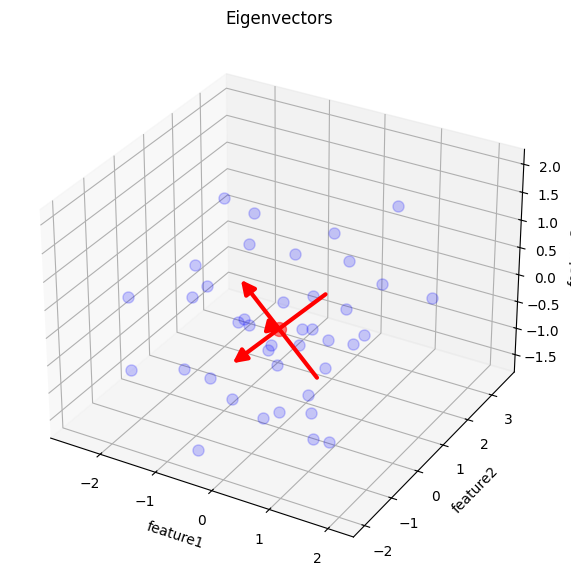

In [99]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        return np.min(zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        super().draw(renderer)


# --------------------------------------------------
# Create 3D figure
# --------------------------------------------------

fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)


# --------------------------------------------------
# Plot the data points
# --------------------------------------------------

ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)


# --------------------------------------------------
# Calculate mean / centroid
# --------------------------------------------------

mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()


# Plot centroid
ax.plot(
    [mean_x],
    [mean_y],
    [mean_z],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)


# --------------------------------------------------
# Plot eigenvectors
# --------------------------------------------------

for v in eigen_vectors.T:

    # Make the vector pass through the mean
    start = np.array([
        mean_x - v[0],
        mean_y - v[1],
        mean_z - v[2]
    ])

    end = np.array([
        mean_x + v[0],
        mean_y + v[1],
        mean_z + v[2]
    ])

    arrow = Arrow3D(
        [start[0], end[0]],
        [start[1], end[1]],
        [start[2], end[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="red"
    )

    ax.add_artist(arrow)


# --------------------------------------------------
# Labels
# --------------------------------------------------

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.title('Eigenvectors')

plt.show()

In [100]:
pc= eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [101]:
pc1=pc[0]
pc2=pc[1]
pc1

array([-0.53875915, -0.69363291,  0.47813384])

In [102]:
## transforming the points

transformed_df= np.dot(df.iloc[:,0:3],pc.T) 

## Data shape is (40,3) and pc.T (3,2) --> (40,2)
new_df= pd.DataFrame(transformed_df, columns=['PC1','PC2'])
new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [103]:
new_df['target']=new_df['target'].astype('str')

fig=px.scatter(x=new_df['PC1'],y=new_df['PC2'],color=new_df['target'], color_discrete_sequence=px.colors.qualitative.G10)
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))
fig.show()

## Practical Example on MNIST Dataset

In [104]:
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/Datasets/mnist.csv')
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [105]:
df.head().shape

## 785 columns
## 784 pixels and 1 target

(5, 785)

In [106]:
df.shape

(42000, 785)

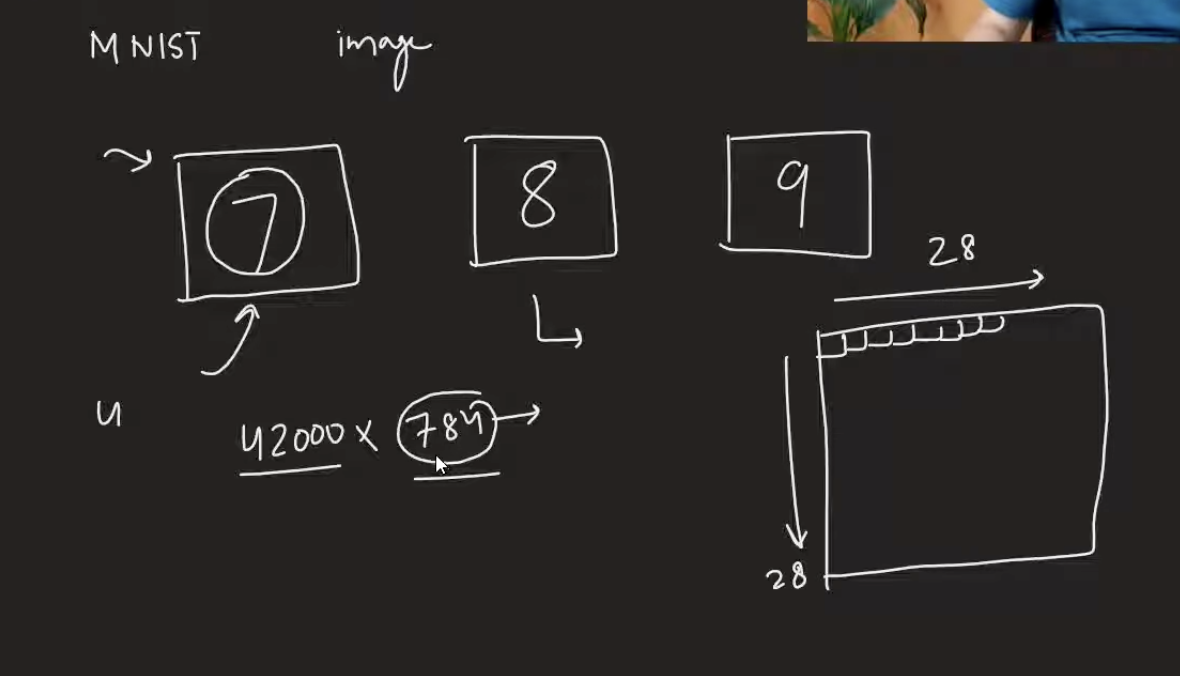

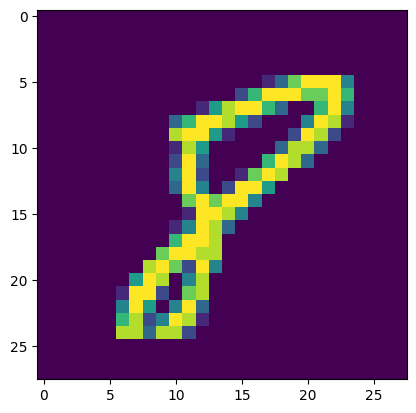

In [107]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

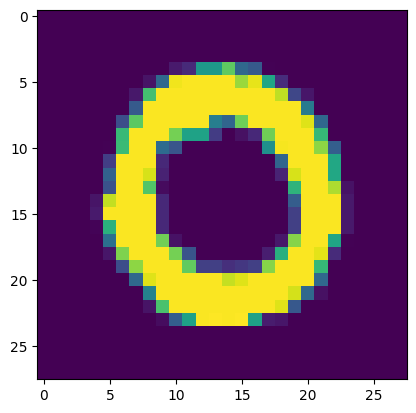

In [108]:
plt.imshow(df.iloc[1,1:].values.reshape(28,28)) ## 784= 28 X 28

In [109]:
X=df.iloc[:,1:]
y=df.iloc[:,0]


In [110]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [111]:
X_train

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
34941,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24433,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24432,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8832,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30291,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11284,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38158,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [112]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [113]:
import time
start=time.time()
y_pred=knn.predict(X_test)
print(time.time()-start)

7.626859903335571


In [114]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.9648809523809524

In [115]:
## I will use PCA and try to gain accuracy similar to it with less dimensions

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



In [116]:
## PCA

from sklearn.decomposition import PCA
## PCA(no of principal components) it can have any number or None. None means you get no of Principal components = total features
pca=PCA(n_components=100)

X_train_trf=pca.fit_transform(X_train) ## you find eigen values and eigen vectors and then you transform your data
X_test_trf=pca.transform(X_test)


In [117]:
X_train.shape

(33600, 784)

In [118]:
X_train_trf.shape

(33600, 100)

In [120]:
knn=KNeighborsClassifier()

knn.fit(X_train_trf,y_train)
y_pred=knn.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.9544047619047619

In [122]:
max_score=0
for i in range(1,785):
    pca=PCA(n_components=i)
    X_train_trf=pca.fit_transform(X_train)
    X_test_trf=pca.transform(X_test)
    knn=KNeighborsClassifier()
    knn.fit(X_train_trf,y_train)
    y_pred=knn.predict(X_test_trf)
    score=accuracy_score(y_test,y_pred)
    print(i, score)
    if max_score < score:
        max_score=score

print('max_score is:',max_score)

1 0.2580952380952381
2 0.3236904761904762
3 0.5104761904761905
4 0.6663095238095238
5 0.7378571428571429
6 0.8227380952380953
7 0.8436904761904762
8 0.8721428571428571
9 0.886547619047619
10 0.9055952380952381
11 0.9116666666666666
12 0.9184523809523809
13 0.9276190476190476
14 0.9351190476190476
15 0.9384523809523809
16 0.9379761904761905
17 0.9407142857142857
18 0.94
19 0.9425
20 0.9442857142857143
21 0.9438095238095238
22 0.9441666666666667
23 0.9442857142857143
24 0.9457142857142857
25 0.9484523809523809
26 0.9479761904761905
27 0.9478571428571428
28 0.9471428571428572
29 0.949047619047619
30 0.9491666666666667
31 0.9507142857142857
32 0.9513095238095238
33 0.95
34 0.9504761904761905
35 0.950952380952381
36 0.9519047619047619
37 0.9517857142857142
38 0.9527380952380953
39 0.9533333333333334
40 0.9528571428571428
41 0.9522619047619048
42 0.9522619047619048
43 0.9523809523809523
44 0.9533333333333334
45 0.9528571428571428
46 0.9530952380952381
47 0.9530952380952381
48 0.9533333333333

## Visualization

In [123]:
## transforming to a 2D coordinate system

pca = PCA (n_components=2)
X_train_trf=pca.fit_transform(X_train)
X_test_trf= pca.transform(X_test)


In [124]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

In [125]:
import plotly.express as px

y_train_trf=y_train.astype('str')
fig= px.scatter(x=X_train_trf[:,0],y=X_train_trf[:,1],color=y_train_trf,color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [126]:
## transforming in 3d

pca = PCA (n_components=3)
X_train_trf=pca.fit_transform(X_train)
X_test_trf= pca.transform(X_test)


In [127]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

In [130]:
import plotly.express as px

y_train_trf=y_train.astype('str')
fig= px.scatter_3d(x=X_train_trf[:,0],y=X_train_trf[:,1],z= X_train_trf[:,2],color=y_train_trf,color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

## Attributes in PCA object

In [136]:
# explained_variance_
## we know currently pca we have n_components=3
pca.explained_variance_
## explain_variance_ = eigen_values
## top 3 eigen values 

array([40.67111198, 29.17023401, 26.74459621])

In [134]:
## Eigen Vectors

pca.components_
## you will find set of 3 vectors in 784 dimensional space

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(3, 784))

In [135]:
pca.components_.shape

(3, 784)

In [ ]:
## no of principal components
pca.n_components_

3

## Finding optimum number of principal components:

Earlier we used a loop but that is not an efficient way

Suppose your original dataset has 160 features.

You apply PCA:

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X)

PCA creates up to 160 principal components:

PC1,PC2,PC3,.... ,PC160

Each PC is a new direction in the data. Along with these PCs, PCA gives you eigenvalues.

For example:

λ1=780, λ2=225, λ3=60, ...etc


## What does an eigenvalue mean here?

The eigenvalue corresponding to a principal component tells you how much variance that principal component captures from the original data. Think of variance as information/spread present in the dataset.

Note: eigenvalue alone isn't a percentage

Suppose: λ1=780 , you cannot say that PC1 explains 780% variance. 780 is the amount of variance, not the percentage. We need to convert it into percentage 


## How do we calculate explained variance percentage?

We divide the eigenvalue of a particular PC by the sum of all eigenvalues.

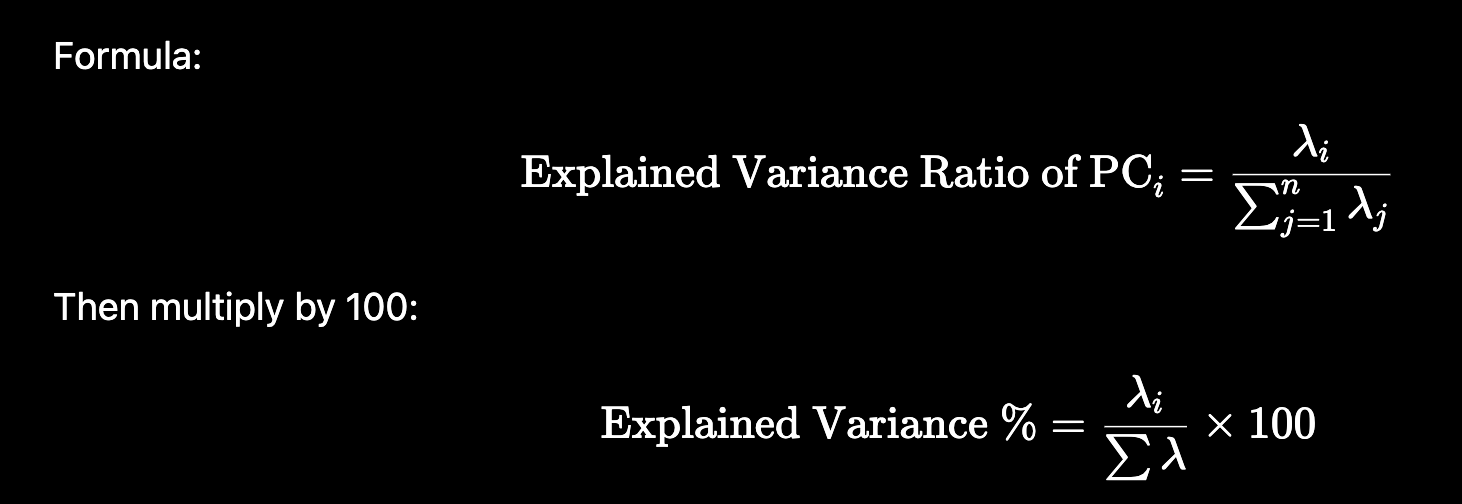

780, 225, 60, 50, 40,…

Suppose the sum of all eigenvalues is:

∑λ=1000

Then PC1 explains: 780/1000 * 100 = 78%

PC2: 225/1000 * 100 = 22.5 %

PC3: 60/1000 * 100 = 6% And so on

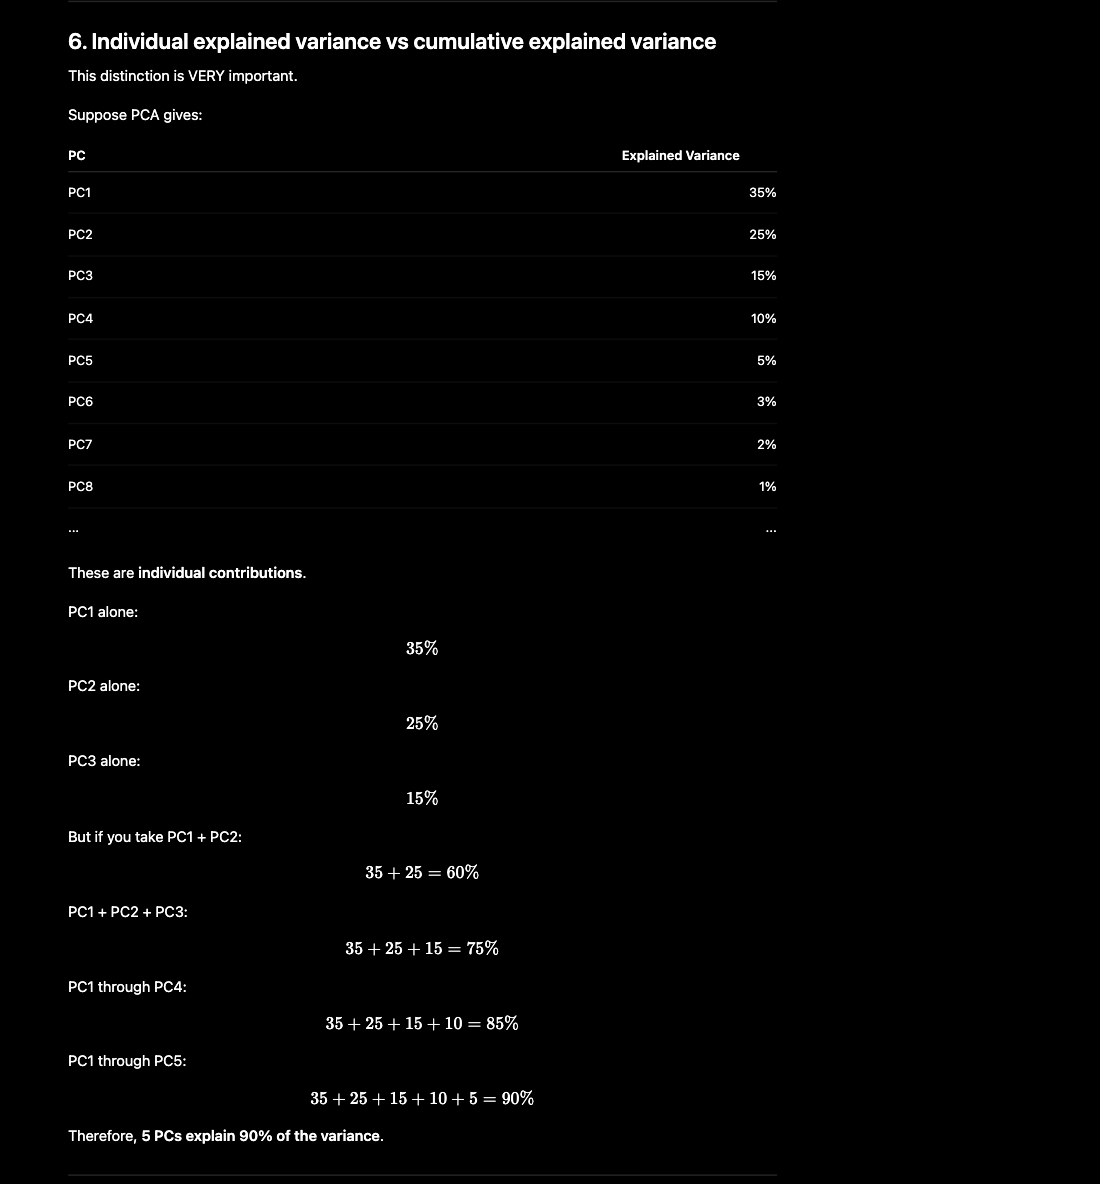

This is what "optimum number of components" means Suppose you originally have 160 features 

You don't necessarily want to keep all 160.

You might discover: The first 15 principal components explain 90% of the total variance.

Then you can reduce: 160 dimensions --> 15 dimensions while retaining approximately 90% of the variance. That's the whole purpose of this exercise.

## Why do we choose 90% ?

There is no universal rule that it must be 90%.

Common choices are:

- 90%
- 95%
- 99%

It depends on the problem. For example: Aggressive dimensionality reduction

Use: 90%  , You may lose some information but dramatically reduce dimensions.

More conservative, Use: 95%


Very little information loss, Use: 99% 

Keep adding principal components until their cumulative explained variance reaches the required threshold, such as 90%."

In [139]:
## this tells you the ratio of explained variance basically  λi / ∑λ
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

# Creating PCA to find optimum number

In [140]:
pca=PCA(n_components=None)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)


In [143]:
pca.explained_variance_.shape

(784,)

In [144]:
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(784, 784))

In [145]:
pca.explained_variance_ratio_

array([5.78519225e-02, 4.14926968e-02, 3.80423901e-02, 2.96626277e-02,
       2.58156168e-02, 2.25498018e-02, 1.97306802e-02, 1.77527998e-02,
       1.56865066e-02, 1.43606328e-02, 1.37025484e-02, 1.22725500e-02,
       1.14691200e-02, 1.12302739e-02, 1.05852885e-02, 1.01993106e-02,
       9.57676152e-03, 9.42708817e-03, 9.12489429e-03, 8.90170190e-03,
       8.39940495e-03, 8.20063196e-03, 7.85303229e-03, 7.56739707e-03,
       7.37261022e-03, 7.01884653e-03, 6.97919728e-03, 6.71104483e-03,
       6.39845030e-03, 6.30337291e-03, 6.15350848e-03, 6.02388659e-03,
       5.83673972e-03, 5.78547759e-03, 5.72333148e-03, 5.46399774e-03,
       5.43207369e-03, 5.28172755e-03, 5.13381744e-03, 4.94015474e-03,
       4.87671103e-03, 4.81978768e-03, 4.68204430e-03, 4.59342487e-03,
       4.57660834e-03, 4.49219022e-03, 4.44682221e-03, 4.41540749e-03,
       4.35111936e-03, 4.32032928e-03, 4.21808870e-03, 4.18243127e-03,
       4.07994349e-03, 4.02004913e-03, 3.98335855e-03, 3.94598812e-03,
      

In [148]:
pca.explained_variance_ratio_.cumsum()

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

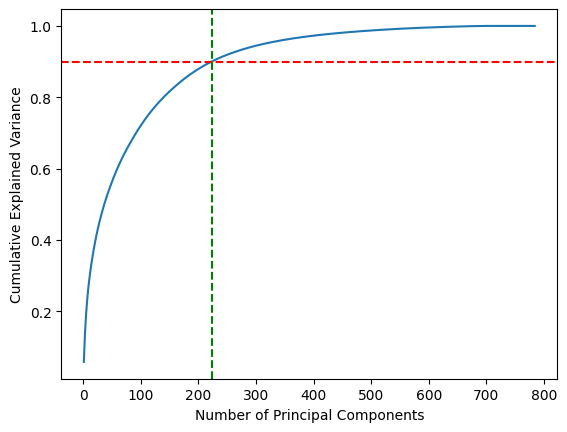

Number of components required: 223


In [154]:
cum_var = pca.explained_variance_ratio_.cumsum()

n_components=np.argmax(cum_var >=0.9)+1
plt.plot(range(1, len(cum_var) + 1), cum_var)
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=n_components, color='g', linestyle='--')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')

plt.show()

print("Number of components required:", n_components)

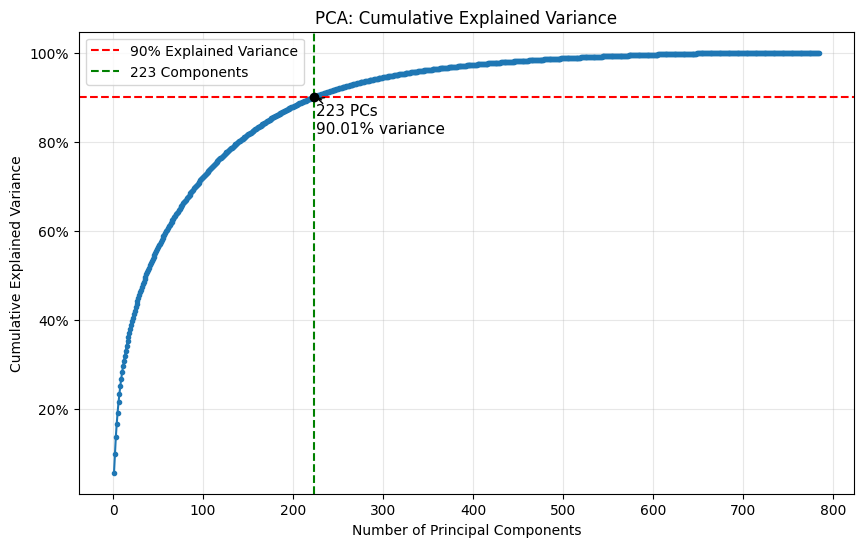

Number of components required: 223


In [155]:
cum_var = pca.explained_variance_ratio_.cumsum()

# Find number of components required for 90% variance
n_components = np.argmax(cum_var >= 0.9) + 1

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cum_var) + 1),
    cum_var,
    marker='o',
    markersize=3
)

# 90% horizontal line
plt.axhline(
    y=0.9,
    color='r',
    linestyle='--',
    label='90% Explained Variance'
)

# Vertical line at required number of PCs
plt.axvline(
    x=n_components,
    color='g',
    linestyle='--',
    label=f'{n_components} Components'
)

# Mark the intersection point
plt.scatter(
    n_components,
    cum_var[n_components - 1],
    color='black',
    zorder=5
)

# Annotate the point
plt.annotate(
    f'{n_components} PCs\n{cum_var[n_components - 1]:.2%} variance',
    xy=(n_components, cum_var[n_components - 1]),
    xytext=(n_components + 3, cum_var[n_components - 1] - 0.08),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

# Labels
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')

# Show percentage on Y-axis
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}')
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("Number of components required:", n_components)

In [156]:
## even easier method
## Scikit-learn can find the required number automatically:
pca = PCA(n_components=0.90)
X_reduced = pca.fit_transform(X)

## When PCA doesn't work ?

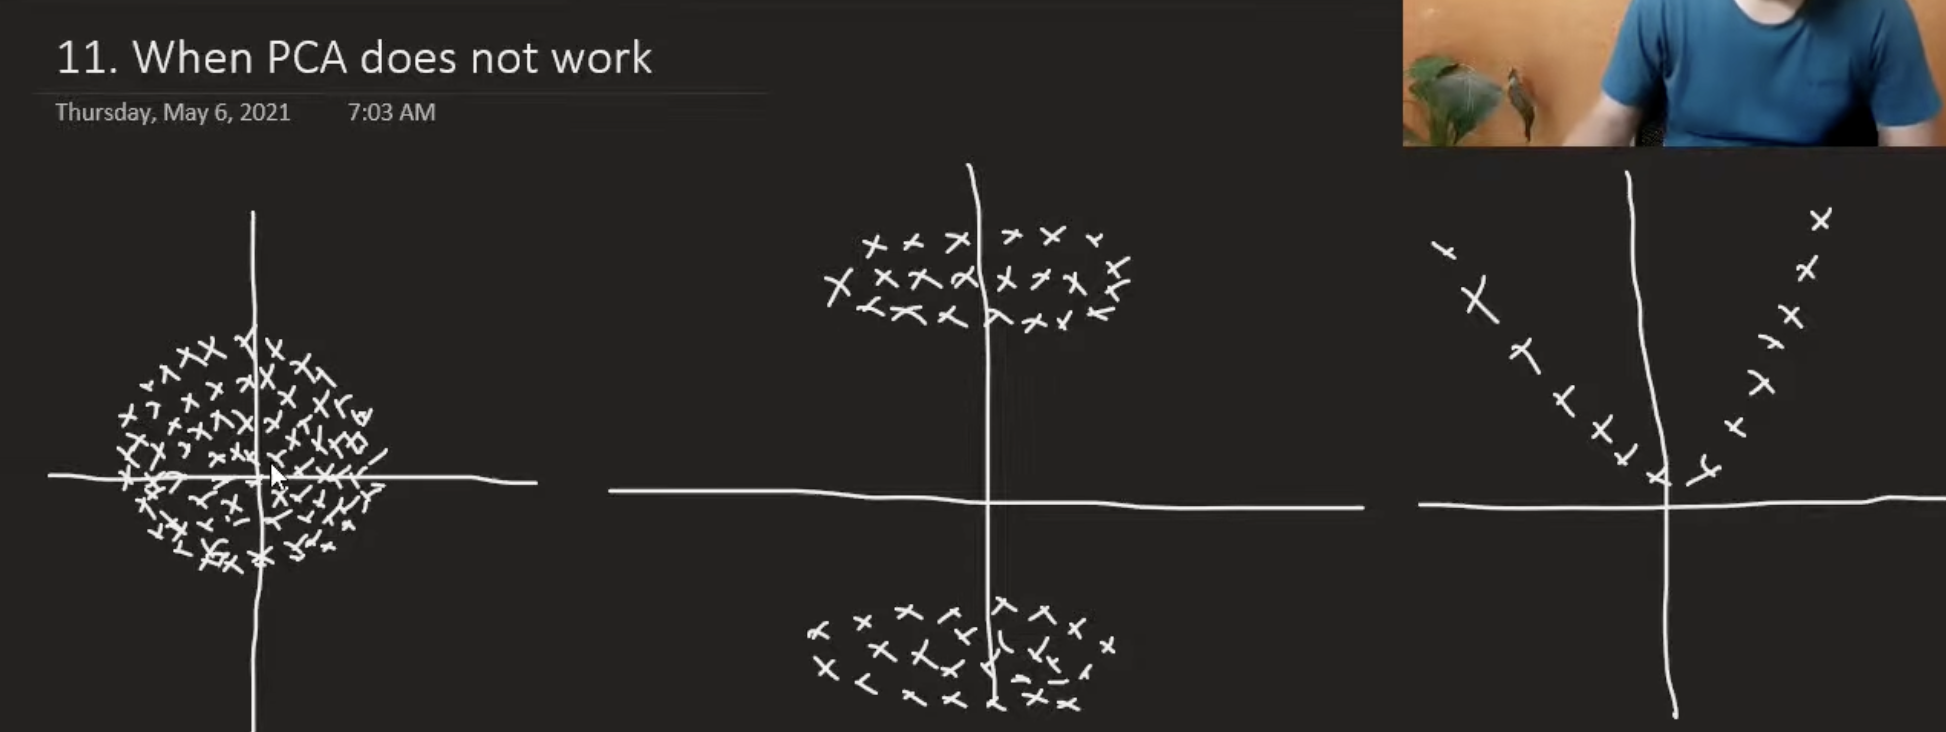

1st case: Circle

Variance about X axis and Variance about y axis is equal. Even if you tilt the axis, in the new x axis and y axis variance will be equal, you cannot choose one dimension 
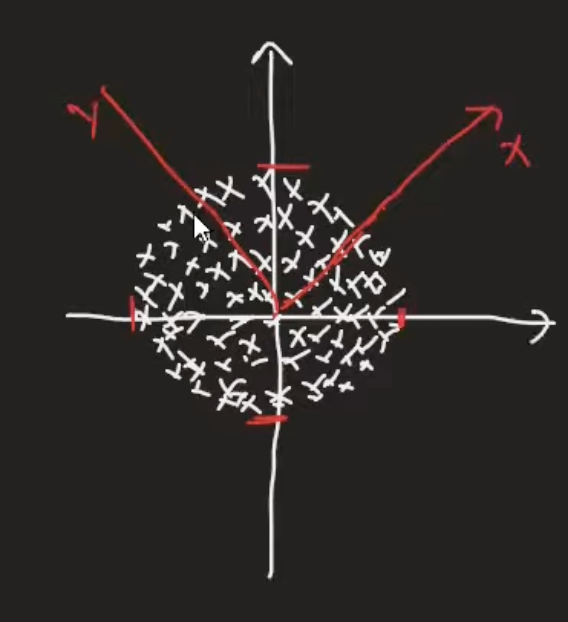

2nd case : openings of cylinder

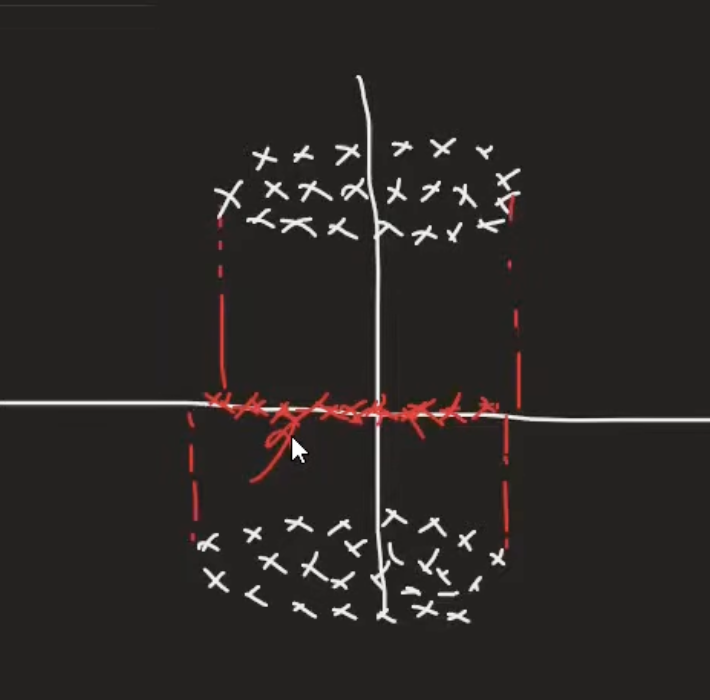

3rd case: Wheen there is a specific pattern in data

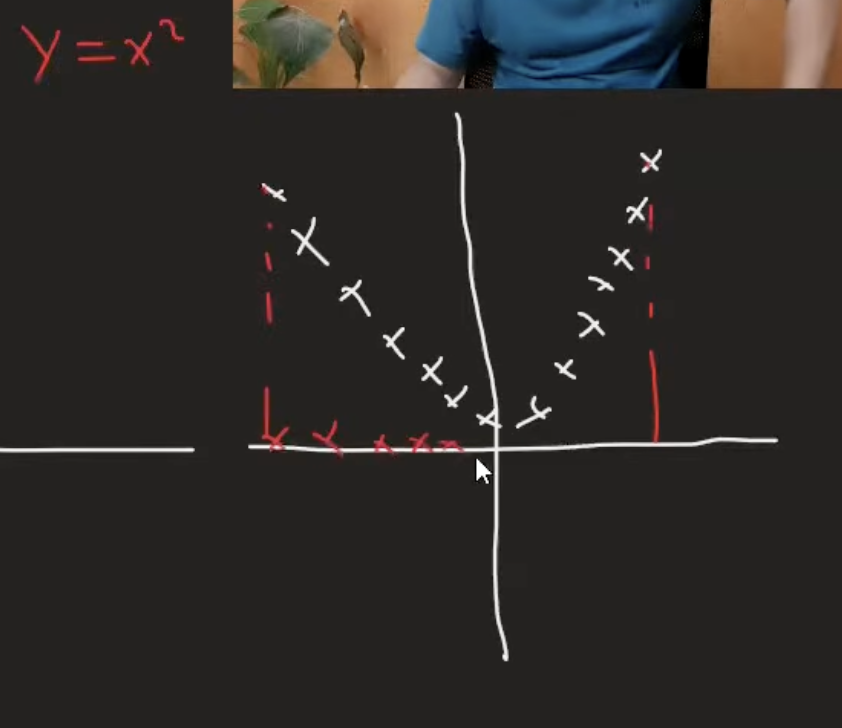

You will loose the pattern in 1D

Same for sine curve

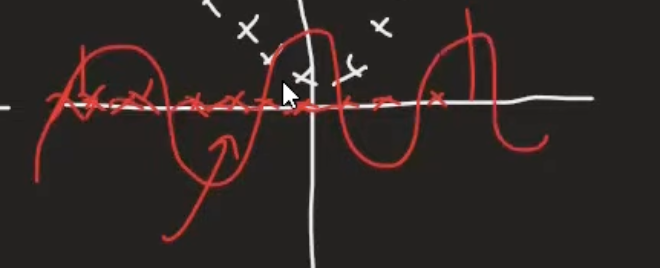

## Matrix Composition

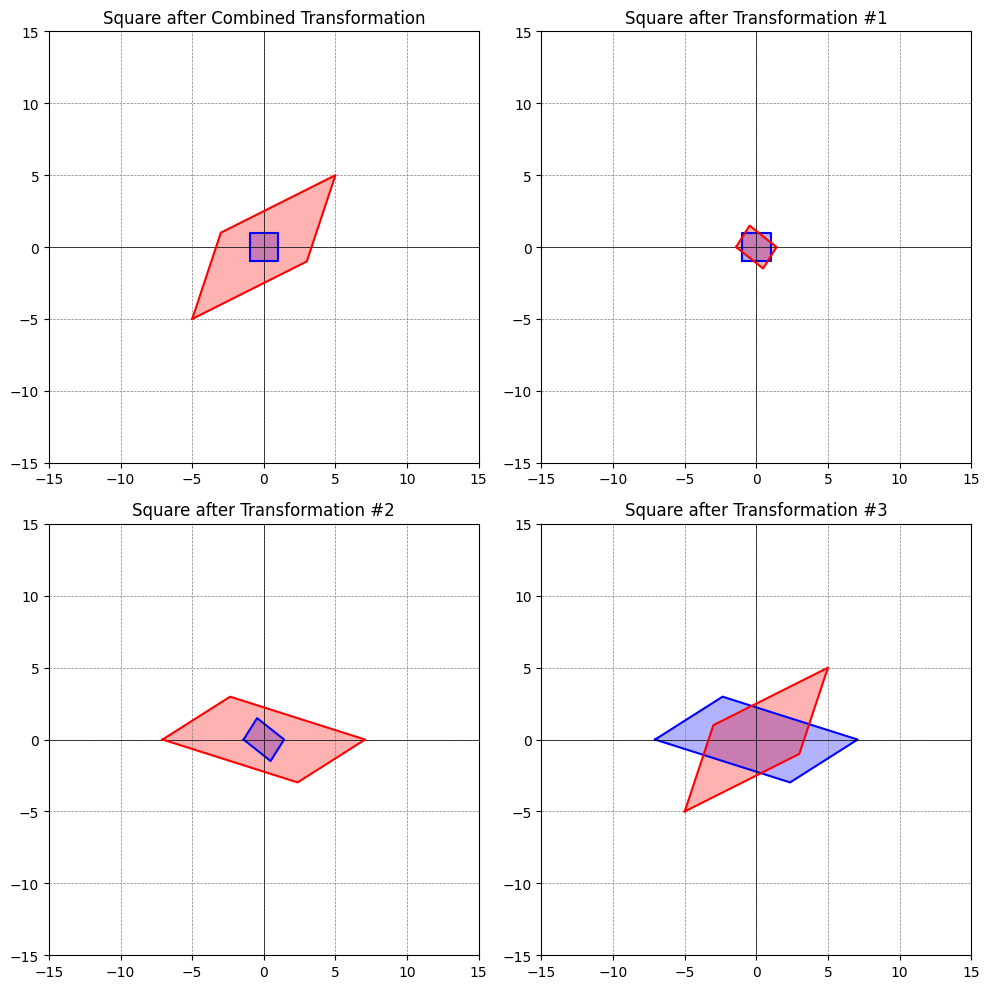

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Plot initial coordinate axis and unit square
def plot_square(ax, square):
    ax.plot(square[0, :], square[1, :], 'b')
    ax.fill(square[0, :], square[1, :], 'blue', alpha=0.3)
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.axhline(0, color='black',linewidth=0.5)
    ax.axvline(0, color='black',linewidth=0.5)
    ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5)

# Apply transformation and plot
def plot_transformed_square(ax, matrix, square):
    transformed_square = np.dot(matrix, square)
    ax.plot(transformed_square[0, :], transformed_square[1, :], 'r')
    ax.fill(transformed_square[0, :], transformed_square[1, :], 'red', alpha=0.3)
    return transformed_square

# Initialize unit square
square = np.array([[-1, -1], [-1, 1], [1, 1], [1, -1], [-1, -1]]).T

# Inputs for 3 2x2 matrices
matrix1 = np.array([[ 0.94280904, 0.47140452], [-0.74535599, 0.74535599]])  # Replace with your matrix
matrix2 = np.array([[5, 0], [0, 2]])  # Replace with your matrix
matrix3 = np.array([[ 0.70710678, -0.4472136 ],[ 0.70710678, 0.89442719]])  # Replace with your matrix
matrices = [matrix1, matrix2, matrix3]

# Calculate product of all three matrices
product_matrix = np.dot(matrix3, np.dot(matrix2, matrix1))

# Create 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot combined transformation as the first graph
plot_square(axs[0, 0], square)
square_combined = plot_transformed_square(axs[0, 0], product_matrix, square)
axs[0, 0].set_title('Square after Combined Transformation')

# Plot individual transformations as the remaining graphs
for i, (matrix, ax) in enumerate(zip(matrices, axs.flat[1:]), start=1):
    plot_square(ax, square)
    square = plot_transformed_square(ax, matrix, square)
    ax.set_title(f'Square after Transformation #{i}')

# Adjust layout to prevent overlapping titles
plt.tight_layout()
plt.show()


Result of 1 transformation and the three transformation are same

In [3]:
# import numpy as np

# # Define your square matrix
# A = np.array([[4, 1], [2, 3]])

# # Perform the eigen decomposition
# eigenvalues, V = np.linalg.eig(A)

# # Create the diagonal matrix of eigenvalues
# Lambda = np.diag(eigenvalues)

# # Compute the inverse of V
# V_inv = np.linalg.inv(V)

# # Verify that A = VΛV^(-1)
# A_reconstructed = np.dot(V, np.dot(Lambda, V_inv))

# # Print the matrices
# print("Matrix V (Eigenvectors of A as columns):")
# print(V)
# print("\nMatrix Λ (Diagonal matrix of Eigenvalues):")
# print(Lambda)
# print("\nInverse of V:")
# print(V_inv)
# print("\nReconstructed A (Should be close to original A):")
# print(A_reconstructed)


import numpy as np 

## define your square matrix

A= np.array([[4,1],[2,3]])

## perform the eigen Decomposition
eigen_values,V=np.linalg.eig(A)

## Create the diagonal matrix of eigenvalues
Lambda=np.diag(eigen_values)

## compute the inverse of V
V_inv=np.linalg.inv(V)

## verift that A= VAV^(-1)
A_reconstructed=np.dot(V,np.dot(Lambda,V_inv))

# Print the matrices
print("Matrix V (Eigenvectors of A as columns):")
print(V)
print("\nMatrix Λ (Diagonal matrix of Eigenvalues):")
print(Lambda)
print("\nInverse of V:")
print(V_inv)
print("\nReconstructed A (Should be close to original A):")
print(A_reconstructed)

Matrix V (Eigenvectors of A as columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Matrix Λ (Diagonal matrix of Eigenvalues):
[[5. 0.]
 [0. 2.]]

Inverse of V:
[[ 0.94280904  0.47140452]
 [-0.74535599  0.74535599]]

Reconstructed A (Should be close to original A):
[[4. 1.]
 [2. 3.]]


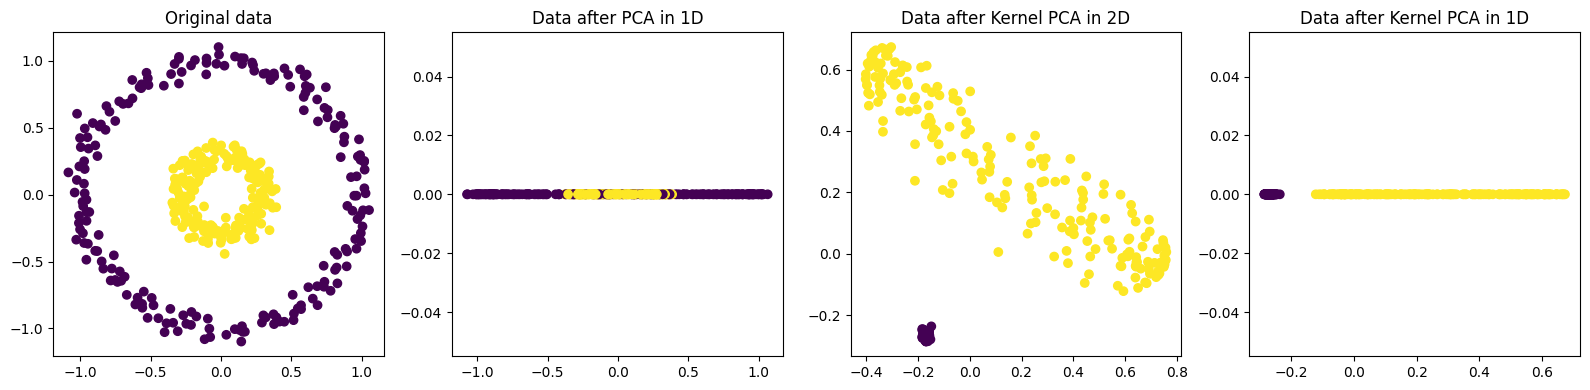

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles

# Generate the dataset
X, y = make_circles(n_samples=400, factor=.3, noise=.05)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Apply Kernel PCA
kpca = KernelPCA(kernel="rbf", gamma=10)
X_kpca = kpca.fit_transform(X)

# Original data plot
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')

# Transformed data with PCA in 1D
plt.subplot(1, 4, 2)
plt.scatter(X_pca[:, 0], np.zeros((400,)), c=y)
plt.title('Data after PCA in 1D')

# Transformed data with Kernel PCA in 2D
plt.subplot(1, 4, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.title('Data after Kernel PCA in 2D')

# Transformed data with Kernel PCA in 1D
plt.subplot(1, 4, 4)
plt.scatter(X_kpca[:, 1], np.zeros((400,)), c=y)
plt.title('Data after Kernel PCA in 1D')

plt.tight_layout()
plt.show()


In kernel pca , result changes everytime you run the algorithm. To find the best principal components, apply a classification algo which calculates accuracy for every case.

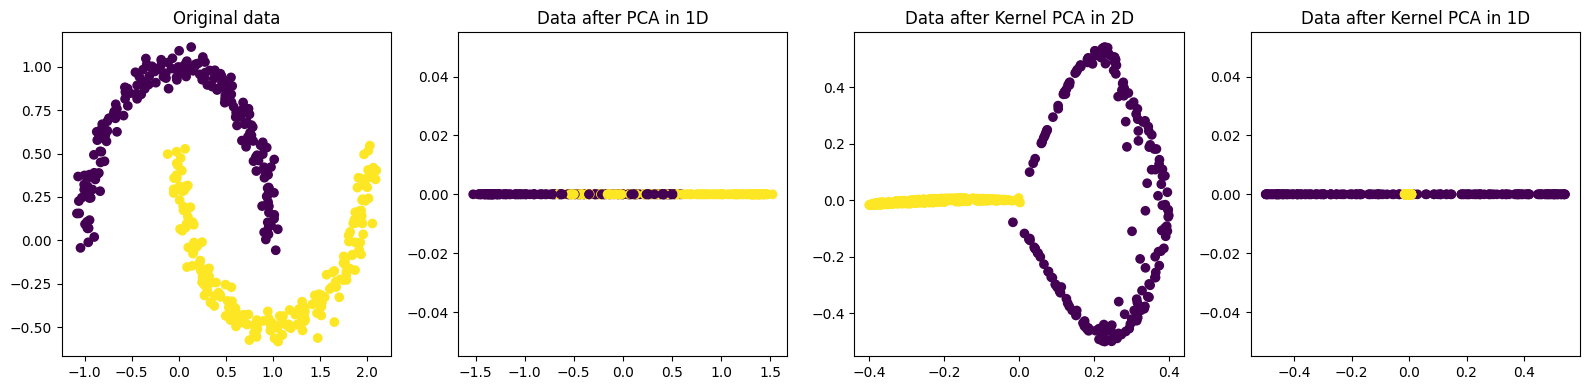

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_moons

# Generate the dataset
X, y = make_moons(n_samples=400, noise=.05)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Apply Kernel PCA
kpca = KernelPCA(kernel="rbf", gamma=15)
X_kpca = kpca.fit_transform(X)

# Original data plot
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')

# Transformed data with PCA in 1D
plt.subplot(1, 4, 2)
plt.scatter(X_pca[:, 0], np.zeros((400,)), c=y)
plt.title('Data after PCA in 1D')

# Transformed data with Kernel PCA in 2D
plt.subplot(1, 4, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.title('Data after Kernel PCA in 2D')

# Transformed data with Kernel PCA in 1D
plt.subplot(1, 4, 4)
plt.scatter(X_kpca[:, 1], np.zeros((400,)), c=y)
plt.title('Data after Kernel PCA in 1D')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import plotly.graph_objs as go
# Create the half moon data
X, y = make_moons(n_samples=500, noise=0.02)

print(X)
print(y)
print(len(X))

[[ 6.14151435e-01 -4.12946370e-01]
 [-2.56252861e-02  1.00728725e+00]
 [ 1.03883503e-01  3.76734683e-02]
 [ 5.50815706e-01 -3.88387278e-01]
 [ 1.92427943e+00  1.63845694e-01]
 [ 1.01124334e+00 -4.84406741e-01]
 [-1.00741688e+00  1.52637774e-01]
 [ 1.88876463e+00  2.19379429e-02]
 [ 1.02081382e+00  1.35488265e-01]
 [ 9.68056908e-02  1.00181260e+00]
 [ 1.32467263e-01 -2.20101104e-02]
 [ 1.32018063e-01  1.60384019e-02]
 [-8.95019424e-01  4.63944782e-01]
 [ 9.61398795e-01  2.42977769e-01]
 [ 1.81077212e+00 -9.65581575e-02]
 [-6.66050617e-01  7.29772624e-01]
 [ 1.60513842e+00 -3.07464292e-01]
 [ 4.62407477e-01 -3.00205801e-01]
 [ 3.10590039e-02  1.04477297e+00]
 [ 1.71716273e+00 -2.02262336e-01]
 [-5.46744574e-01  8.46089053e-01]
 [ 9.82207846e-01 -4.85840793e-01]
 [ 8.50546001e-02  6.75091994e-02]
 [ 1.76699387e+00 -1.60860134e-01]
 [-6.76927468e-01  7.39483807e-01]
 [ 1.40758509e+00 -4.46001516e-01]
 [ 1.21239871e+00 -4.96137427e-01]
 [-6.38346203e-01  7.87339092e-01]
 [ 1.86178040e+00  5

In [21]:
# Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

len(X_std[y==1])

250

In [ ]:

# Apply the RBF kernel PCA 
kpca = KernelPCA(n_components=3, kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X_std)

# Create a trace for the original data
trace1 = go.Scatter(x=X_std[y==0, 0], y=X_std[y==0, 1], 
                    mode='markers', name='Class 0',
                    marker=dict(color='red', size=5, opacity=0.5))
trace2 = go.Scatter(x=X_std[y==1, 0], y=X_std[y==1, 1], 
                    mode='markers', name='Class 1',
                    marker=dict(color='blue', size=5, opacity=0.5))

# Create a trace for the transformed data
trace3 = go.Scatter3d(x=X_kpca[y==0, 0], y=X_kpca[y==0, 1], z=X_kpca[y==0, 2], 
                      mode='markers', name='Class 0',
                      marker=dict(color='red', size=5, opacity=0.5))
trace4 = go.Scatter3d(x=X_kpca[y==1, 0], y=X_kpca[y==1, 1], z=X_kpca[y==1, 2], 
                      mode='markers', name='Class 1',
                      marker=dict(color='blue', size=5, opacity=0.5))

# Create the layouts
layout1 = go.Layout(title='Original data in 2D', autosize=True, 
                    xaxis=dict(title='Feature 1'),
                    yaxis=dict(title='Feature 2'))
layout2 = go.Layout(title='Data after RBF Kernel PCA in 3D', autosize=True, 
                    scene=dict(xaxis=dict(title='PC 1'),
                               yaxis=dict(title='PC 2'),
                               zaxis=dict(title='PC 3')))

# Create the figures and plot
fig1 = go.Figure(data=[trace1, trace2], layout=layout1)
fig2 = go.Figure(data=[trace3, trace4], layout=layout2)

fig1.show()
fig2.show()

## Kernel PCA Step by Step

Text(0.5, 1.0, 'Original data')

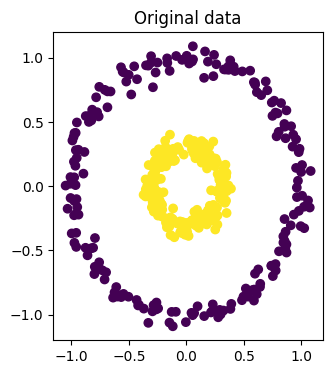

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
import numpy as np

# Generate the dataset
X, y = make_circles(n_samples=400, factor=.3, noise=.05)

# Original data plot
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')

In [31]:
X.shape

## we need to find PC1 only which best separates yellow and purple points

(400, 2)

In [32]:
## step 1
X_centered = X - np.mean(X, axis=0)

Text(0.5, 1.0, 'Original data')

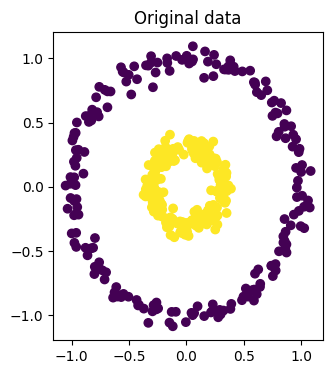

In [28]:
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.scatter(X_centered[:, 0], X_centered[:, 1], c=y)
plt.title('Original data')

## RBF Kernel

y= e ^ -(gamma * (distance**2))

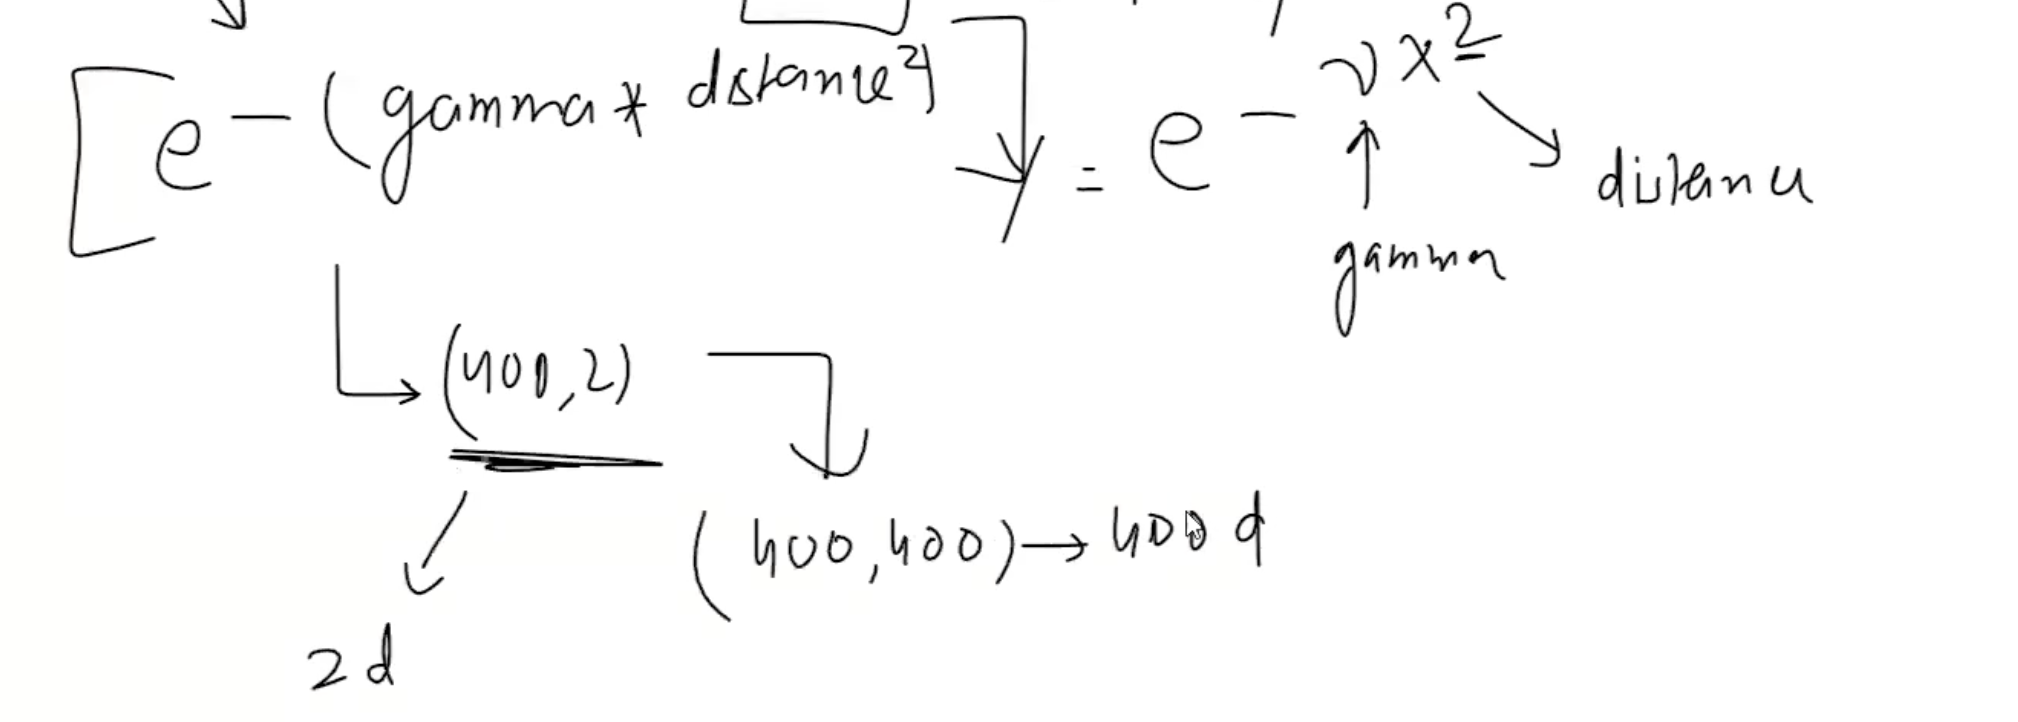

You first convert the data to 400 dimension not 3d

(400,2) -> (400,400)

find eucledian distance of each row with every other row


row 1-> dist(row1,row1),dist(row1,row2), dist(row1,row3), dist(row1,row4),... dist(row1,row400) (400 times)

row 2-> dist(row2,row1), dist(row2,row2), dist(row2,row3),..... dist(row2,row400) (400 times)

.
.
.

row 400 -> ...

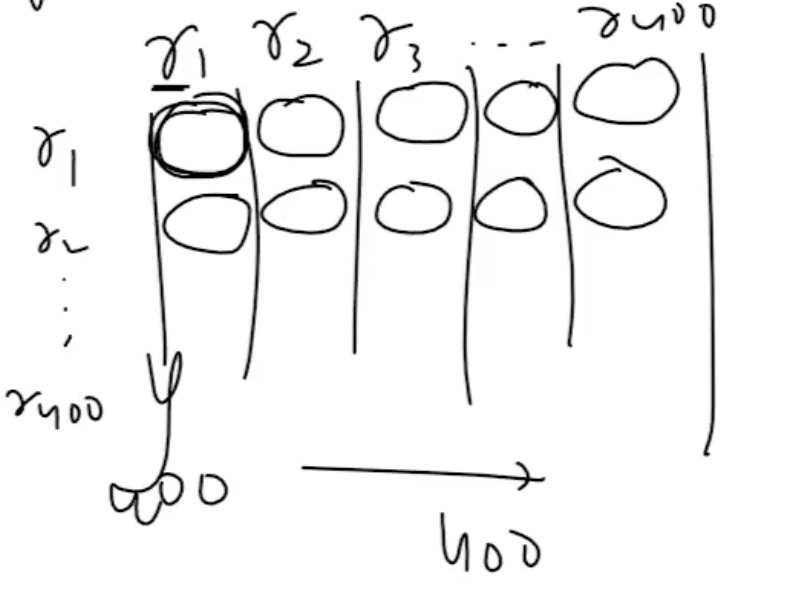

400 X 400 distances

this is a similarity matrix -> high values means two points have high similarity 

low value means two points are highly dissimilar

you find square of distances then

Then you do eigen decomposition of 400 X 400 matrix  -> 400 Eigen vectors we get -> since the matrix is symmetrical therefore the eigen vectors are orthogonal -> choose the best k eigen vectors

In [34]:
def rbf_kernel(row1,row2,gamma=0.1):
    dist=np.linalg.norm(row1-row2)**2
    return np.exp(- gamma * dist)   

## create the kernel matrix
n_samples=X.shape[0]
K= np.zeros((n_samples,n_samples))
for i in range(n_samples):
    for j in range(n_samples):
        K[i,j]=rbf_kernel(X_centered[i],X_centered[j])

In [36]:
K.shape

(400, 400)

In [37]:
## eigen decomposition of K
from scipy.linalg import eigh
eigenvalues,eigenvectors=eigh(K)

In [38]:
eigenvectors.shape

(400, 400)

In [ ]:
## Reverse the array as eigh returns them in ascending order

eigen_values=eigenvalues[::-1]
eigen_vectors=eigenvectors[:,::-1]

In [ ]:
k=2
X_kpca=eigen_vectors[:,:k] ## only 2 columns are required


In [41]:
X_kpca.shape

(400, 2)

Text(0.5, 1.0, 'Data after kernel pca in 1D')

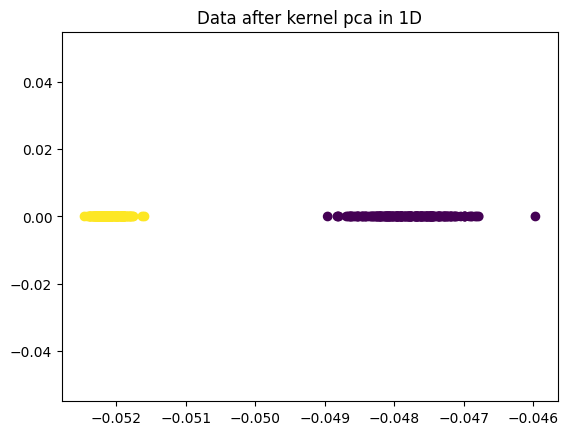

In [42]:
plt.scatter(X_kpca[:,0],np.zeros((400,)),c=y)
plt.title('Data after kernel pca in 1D')

Text(0.5, 1.0, 'Data after kernel pca in 1D')

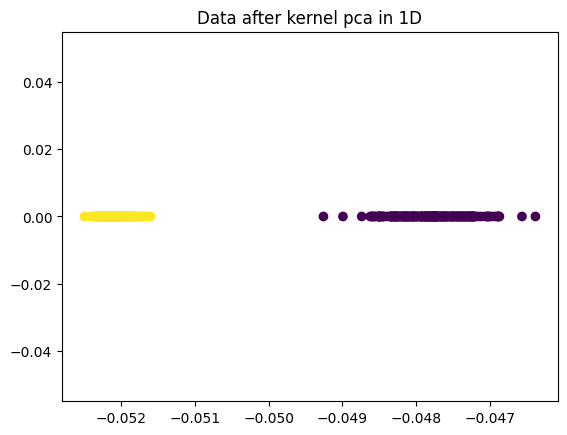

In [56]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
import numpy as np

# Generate the dataset
X, y = make_circles(n_samples=400, factor=.3, noise=.05)

X_centered = X - np.mean(X, axis=0)
def rbf_kernel(row1,row2,gamma=0.1):
    dist=np.linalg.norm(row1-row2)**2
    return np.exp(- gamma * dist)   

## create the kernel matrix
n_samples=X.shape[0]
K= np.zeros((n_samples,n_samples))
for i in range(n_samples):
    for j in range(n_samples):
        K[i,j]=rbf_kernel(X_centered[i],X_centered[j])


## eigen decomposition of K
from scipy.linalg import eigh
eigenvalues,eigenvectors=eigh(K)
## Reverse the array as eigh returns them in ascending order

eigen_values=eigenvalues[::-1]
eigen_vectors=eigenvectors[:,::-1]

k=2
X_kpca=eigen_vectors[:,:k] ## only 2 columns are required

plt.scatter(X_kpca[:,0],np.zeros((400,)),c=y)
plt.title('Data after kernel pca in 1D')